In [3]:
# 📦 Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

# 📊 Visualization Settings
%matplotlib inline
sns.set(style="whitegrid")

# 🔧 Preprocessing Tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    RobustScaler, QuantileTransformer, OneHotEncoder,
    LabelEncoder, StandardScaler
)
from sklearn.impute import SimpleImputer

# 🧠 Feature Selection
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, RFE

# 🤖 Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 🚀 Boosting Libraries
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# 🧪 Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, auc,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, mean_squared_error
)


ModuleNotFoundError: No module named 'catboost'

In [2]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [5]:
# read and open the data
df = pd.read_csv('income_data.csv')

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


open the data

In [6]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


open the last part of the data

In [7]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K


the shape of the dataset

df.shape

In [ ]:
# describe the data

In [8]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
#transpose the decribe

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [ ]:
# information about the data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
# size of the dataset

In [11]:
df.size

732630

In [ ]:
# num of dimension

In [12]:
df.ndim

2

In [ ]:
# num of each data entry in each features of the dataset

In [13]:
df.count()

,0
age,48842
workclass,47879
fnlwgt,48842
education,48842
education-num,48842
marital-status,48842
occupation,47876
relationship,48842
race,48842
sex,48842


In [ ]:
#to get the sum of all null value

In [14]:
df.isnull().sum()

,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


In [ ]:
# missing value and the percentage of the dataset missing and the sorting

In [15]:
missing_value = df.isnull().sum()

In [16]:
missing_percentage = (missing_value/len(df)) * 100

missing_data = pd.DataFrame({'missing value' : missing_value, 'percentage': missing_percentage})

In [17]:
missing_data

,missing value,percentage
age,0,0.000000
workclass,963,1.971664
fnlwgt,0,0.000000
education,0,0.000000
education-num,0,0.000000
marital-status,0,0.000000
occupation,966,1.977806
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


In [ ]:
missing_data = missing_data[missing_data['missing value']>0].sort_values(by=['missing value'])

In [18]:
missing_data

,missing value,percentage
age,0,0.000000
workclass,963,1.971664
fnlwgt,0,0.000000
education,0,0.000000
education-num,0,0.000000
marital-status,0,0.000000
occupation,966,1.977806
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


In [ ]:
# dropping missing value

In [19]:
df.dropna(inplace=True)

In [20]:
#checking to be sure that missing value is removed propertly

In [21]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
#numerical feature and the dataframe for numerical features

In [22]:
num_df = df.select_dtypes(include='number').columns.to_list()

In [23]:
num_df

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [24]:
num_df_dataframe = pd.DataFrame(df,columns=['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week'])

In [25]:
num_df_dataframe

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40
...,...,...,...,...,...,...
48836,33,245211,13,0,0,40
48837,39,215419,13,0,0,36
48839,38,374983,13,0,0,50
48840,44,83891,13,5455,0,40


In [26]:
#categorical features and dataframe for categorical features

In [27]:
cat_df = df.select_dtypes(exclude='number').columns.to_list()

In [28]:
cat_df

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'income']

In [29]:
cat_df_dataframe = pd.DataFrame(df,columns=['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week'])

In [30]:
cat_df_dataframe

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40
...,...,...,...,...,...,...
48836,33,245211,13,0,0,40
48837,39,215419,13,0,0,36
48839,38,374983,13,0,0,50
48840,44,83891,13,5455,0,40


In [ ]:
# i want to get the name of the features in the dataset

In [31]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [32]:
#Displaying Unique values of dataset
display(df['workclass'].unique())
print("=================")
display(df['education'].unique())
print("=================")
display(df['marital-status'].unique())
print("=================")
display(df['occupation'].unique())
print("=================")
display(df['relationship'].unique())
print("=================")
display(df['race'].unique())
print("=================")
display(df['income'].unique())

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', '?', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

array(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo',
       'Other'], dtype=object)

array(['<=50K', '>50K'], dtype=object)

In [33]:
# It can be observed that there are rows in our dataset with "?" observed in wor
#Droping the number of rows with '?' value
# Drop the rows with '?' value

df = df.drop(df[df['workclass'] == '?'].index)
df = df.drop(df[df['occupation'] == '?'].index)
# Re-checking to see the unique values
display(df['workclass'].unique())
display(df['occupation'].unique())

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', 'Self-emp-inc', 'Without-pay'], dtype=object)

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [ ]:
# checking for duplicate value and the  its percentage in the data and then remove duplicate value so the dataset will be clean
# by removing duplicate data the model will be more accurate and effective

In [34]:
df.duplicated().sum()

np.int64(48)

In [35]:
percentage_of_duplicate = (df.duplicated().sum() / len(df)) * 100

In [36]:
percentage_of_duplicate

np.float64(0.10485385993271878)

In [37]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
48836,False
48837,False
48839,False
48840,False


In [38]:
df.drop_duplicates(inplace=True)

In [39]:
df.duplicated().sum()

np.int64(0)

Performing Exploratory Data Analysis (EDA)

Feature Understanding

(Univariate analysis)

plotting Feature Distributions

Bar charts

histogram for knowing the distribution of the data in each feature

Boxplot for detecting outliers

pairplot for general distribution information of the dataset

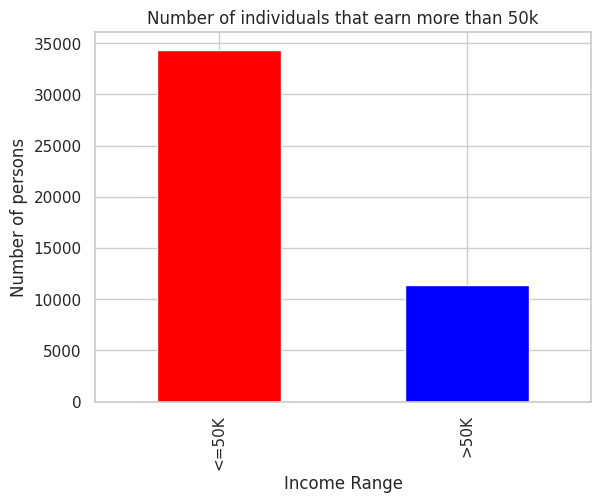

In [40]:
# checking to see number of individuals who earn more than 50k and ones that earn less than 50k
#Plotting on a bar chart
ax = df["income"].value_counts().plot(kind = "bar",
         title = "Number of individuals that earn more than 50k",
        color=['red', 'blue'])
ax.set_xlabel("Income Range")
ax.set_ylabel("Number of persons")
ax.plot()
sns.set_style('darkgrid')

plt.show()

In [ ]:
# using seaborn

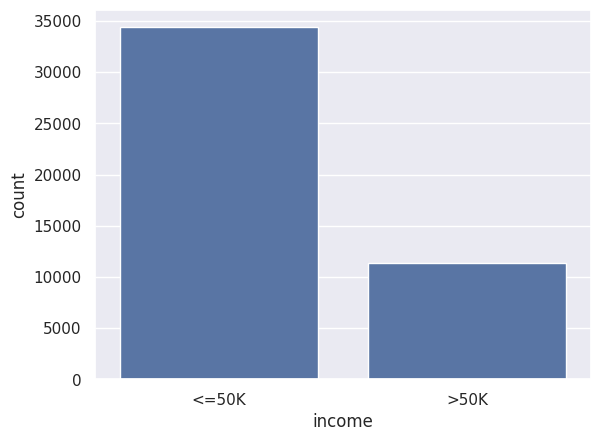

In [41]:
sns.countplot(df,x=df.income)

plt.show()

Second Insight:

Gender Distribution

In [42]:
# checking to see how many times male or female appear
df['sex'].value_counts()

,count
sex,
Male,30902
Female,14828


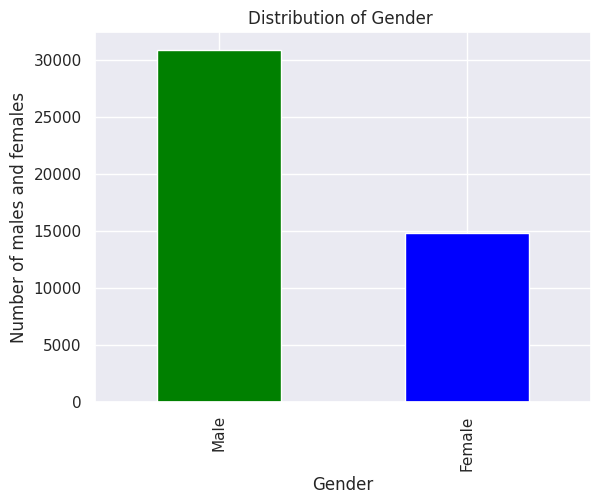

In [43]:
# checking to see the distribution of gender (male and female) in our data
#Plotting on a bar chart
axg = df["sex"].value_counts().plot(kind = "bar",
title = "Distribution of Gender ",
color=['green', 'blue'])
axg.set_xlabel("Gender")
axg.set_ylabel("Number of males and females")
axg.plot()

plt.show()

In [ ]:
#using seaborn

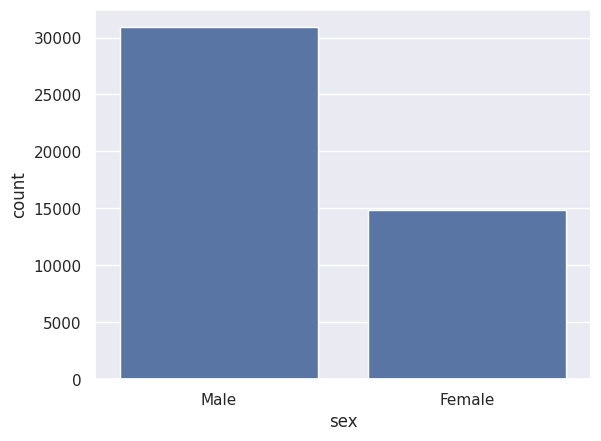

In [44]:
sns.countplot(data=df,x=df.sex)

plt.show()

The Distribution of Gender is skewed greatly to the male sex;

Distribution of males is more than 30,000 whilst

Distribution of females is about 15,000

Feature Relationships

(Bivariate analysis)

Correlation

pie chart

In [ ]:
# get the correction of all the numerical features of the dataset

In [45]:
df_corr_num = df.corr(numeric_only=True)

In [46]:
df_corr_num

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.075629,0.037359,0.079808,0.059421,0.101781
fnlwgt,-0.075629,1.000000,-0.041041,-0.004440,-0.004607,-0.018709
education-num,0.037359,-0.041041,1.000000,0.126815,0.081462,0.145696
capital-gain,0.079808,-0.004440,0.126815,1.000000,-0.032212,0.083216
capital-loss,0.059421,-0.004607,0.081462,-0.032212,1.000000,0.055148
hours-per-week,0.101781,-0.018709,0.145696,0.083216,0.055148,1.000000


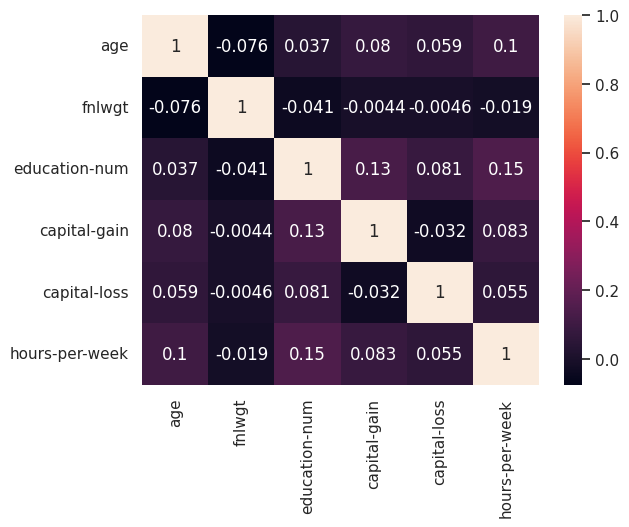

In [47]:
# Using Seaborn heatmap to visualize our correlation analysis
sns.heatmap(df_corr_num, annot = True)

plt.show()

In [48]:
#Checking the correlation between "age", "work hour" and "number of education".
df_corr = df[["age", "hours-per-week", "education-num"]].corr()
df_corr

,age,hours-per-week,education-num
age,1.000000,0.101781,0.037359
hours-per-week,0.101781,1.000000,0.145696
education-num,0.037359,0.145696,1.000000


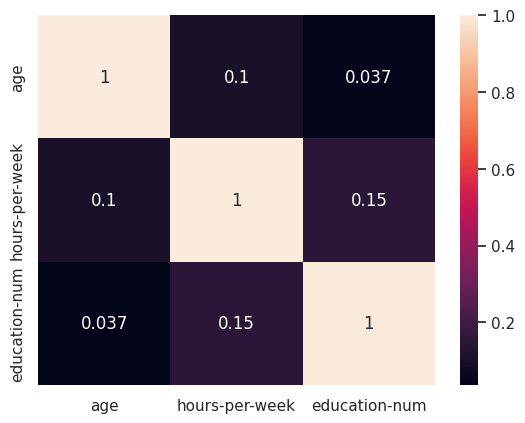

In [49]:
# Using Seaborn heatmap to visualize our correlation analysis
sns.heatmap(df_corr, annot = True)

plt.show()

Fourth Insight: Most prevalent Race in dataset

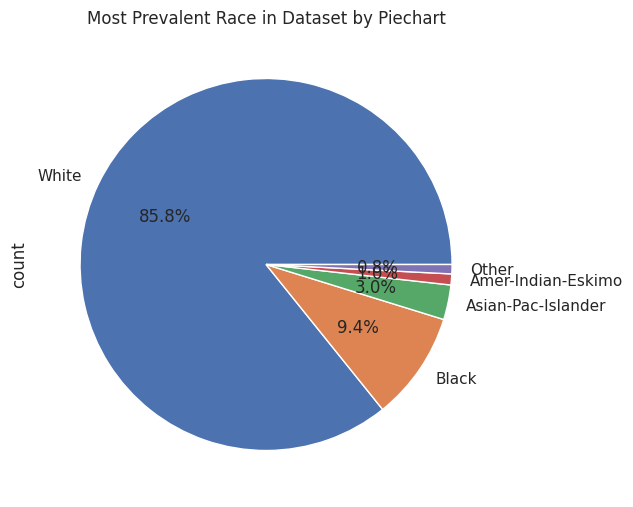

In [50]:
#df["race"].value_counts()
#What Race is the most prevalent in our dataset
# representing it on a pie chart
ax = df["race"].value_counts().plot(kind = "pie",
title = "Most Prevalent Race in Dataset by Piechart",
figsize = (6, 7), autopct = '%1.1f%%')

plt.show()

85.8 percent of individuals by race is skewed to the white, it shows that majority of respondents are white

In [51]:
display(df.nunique())
display(df["income"])

,0
age,74
workclass,7
fnlwgt,26941
education,16
education-num,16
marital-status,7
occupation,14
relationship,6
race,5
sex,2


,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48836,<=50K
48837,<=50K
48839,<=50K
48840,<=50K


Fifth Insight:

Relationship between Gender and income classes

In [52]:
# Gender and Income Levels
# Analyze the relationship between Gender and income classes
gender_income = df.groupby(['sex', 'income']).size().unstack(fill_value=0)
display(gender_income)

income,<=50K,>50K
sex,,
Female,13144,1684
Male,21242,9660


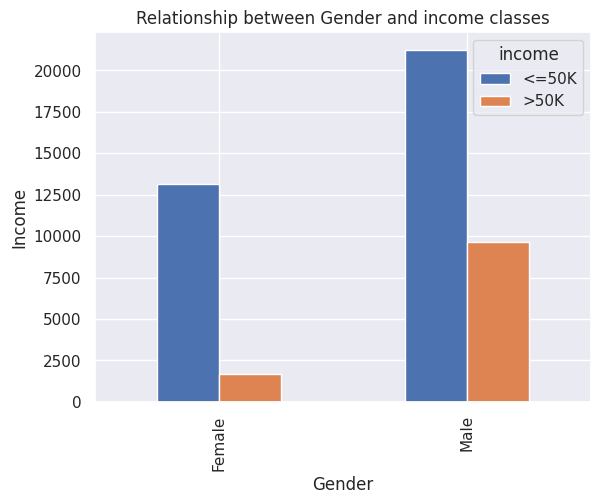

In [53]:
ax = gender_income.plot(kind = "bar",
                title = "Relationship between Gender and income classes")
ax.set_xlabel("Gender")
ax.set_ylabel("Income")
ax.plot()

plt.show()

Sixth Insight:

Relationship between Occupation and income classes

In [54]:
# Occupation and Income Levels
# Analyze the relationship between Occupation and income classes
Occupation_income = df.groupby(['occupation', 'income']).size().unstack(fill_value=0)
display(Occupation_income)

income,<=50K,>50K
occupation,,
Adm-clerical,4819,765
Armed-Forces,10,4
Craft-repair,4704,1375
Exec-managerial,3158,2896
Farming-fishing,1308,172
Handlers-cleaners,1927,138
Machine-op-inspct,2632,369
Other-service,4686,201
Priv-house-serv,233,3


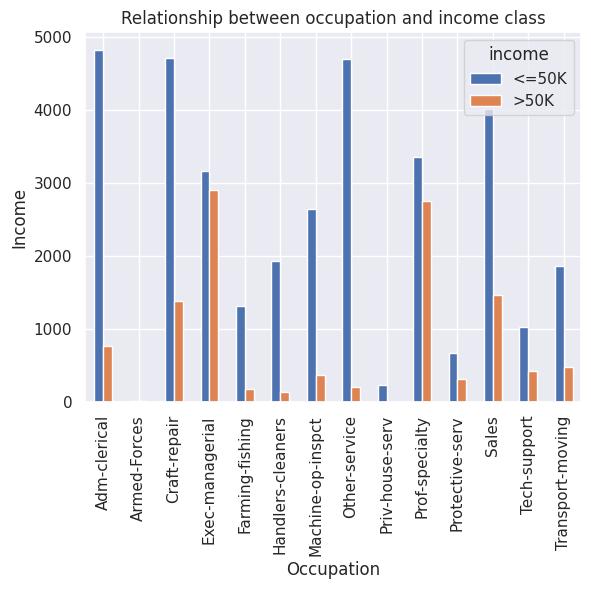

In [55]:
ax = Occupation_income.plot(kind = "bar",
             title = "Relationship between occupation and income class")
ax.set_xlabel("Occupation")
ax.set_ylabel("Income")
ax.plot()

plt.show()

The sixth insight shows that people who earn more than 50k the most are people in:

Executive and managerial positions,

proficient in their specialty,

Sales and

Craft-repair

seven insight

to get the histogram for the numerical fetures

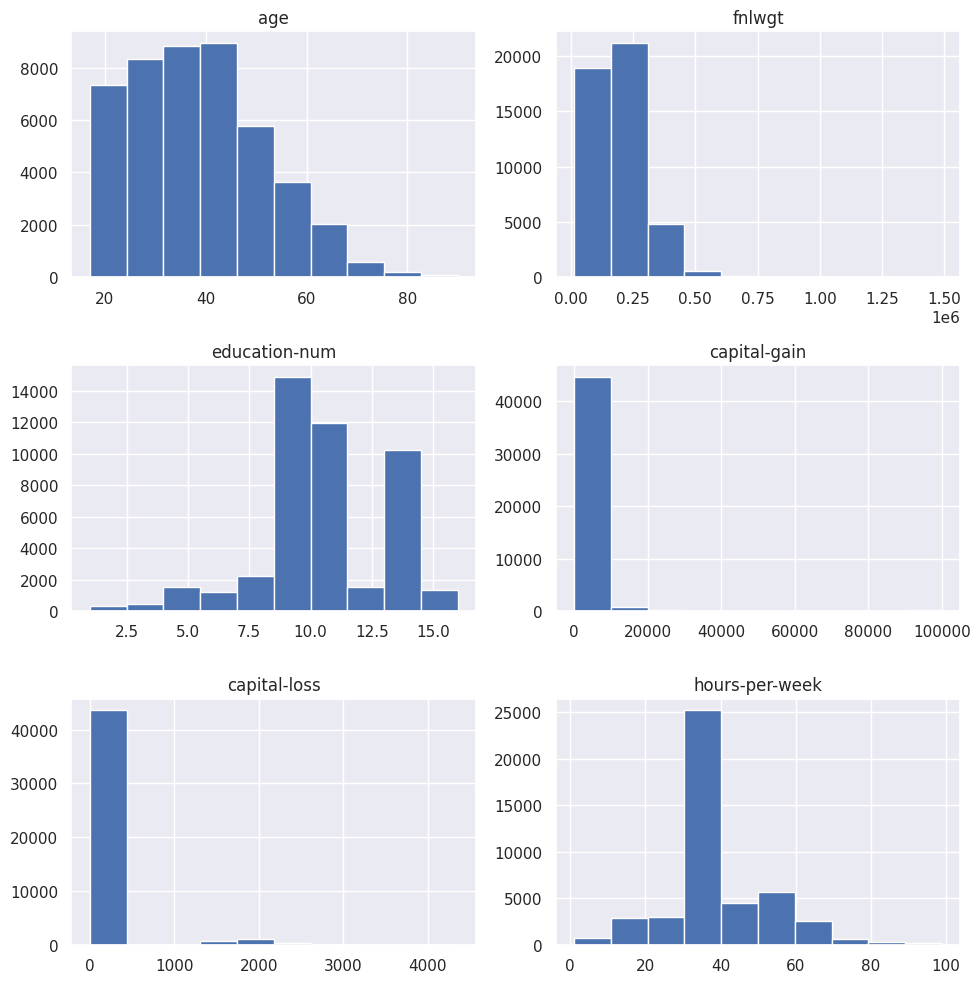

In [56]:
df.select_dtypes(include=['number']).hist(figsize=(10, 10), bins=10)
plt.tight_layout()
plt.show()


there is slight normal distribution in age variable

eight insight


using boxplot to determine the  amount outlier in each of the numerical features of the dataframe

In [57]:
def Box_plots(free):
    plt.figure(figsize=(10, 4))
    plt.title('Box Plot')
    sns.boxplot(free)
    plt.show()

In [ ]:
num_df

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

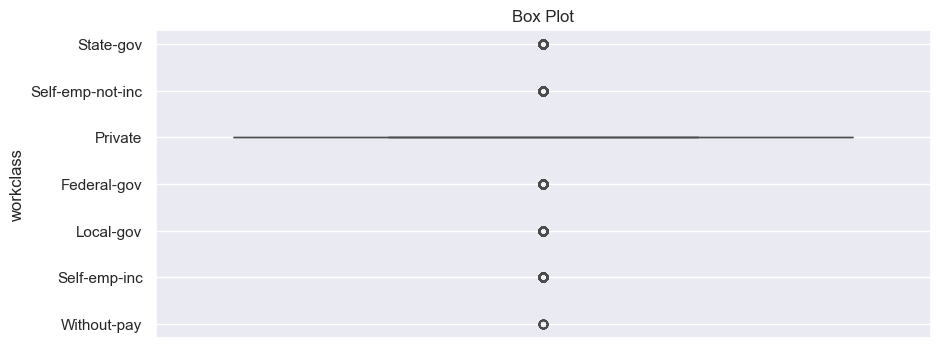

In [ ]:
Box_plots(df['workclass'])

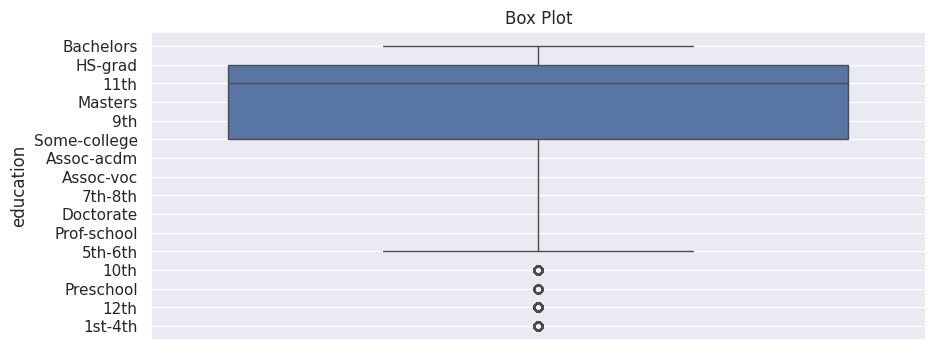

In [58]:
Box_plots(df['education'])

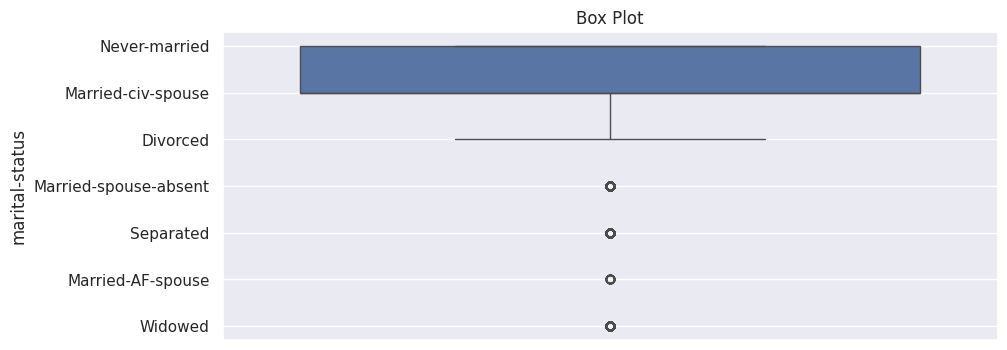

In [59]:
Box_plots(df['marital-status'])

In [60]:
num_df

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

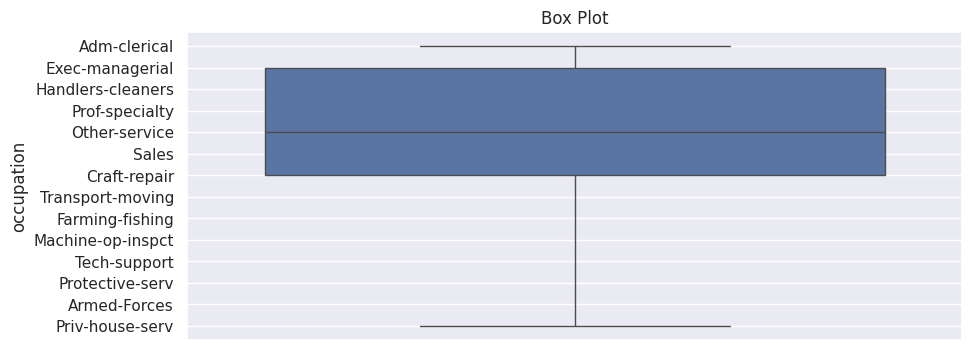

In [61]:
Box_plots(df['occupation'])

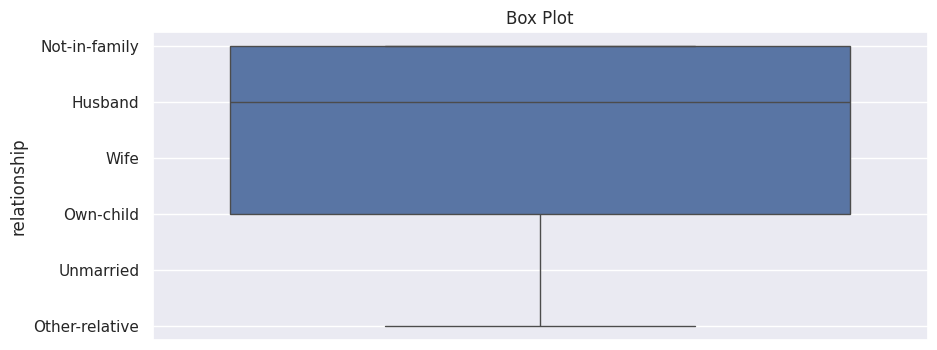

In [62]:
Box_plots(df['relationship'])

there are alot of outliers in world class, education and marital statue

nine insight

boxplot that determine the outliers in the numerical variable of the dataset in relationship to the target variable 'income'

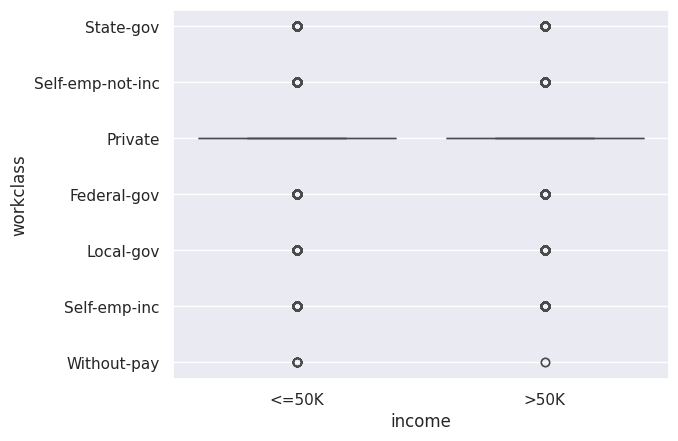

In [63]:
sns.boxplot(data=df,x='income',y='workclass')

plt.show()

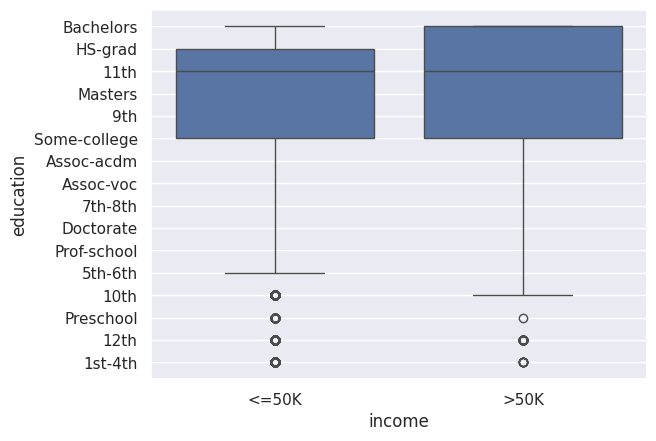

In [64]:
sns.boxplot(data=df,x='income',y='education')

plt.show()

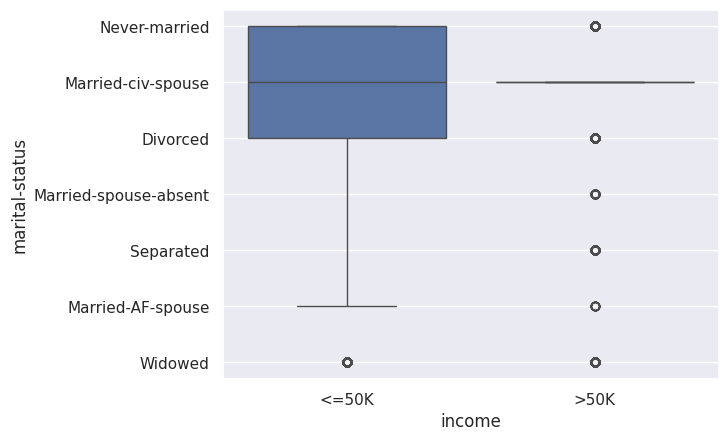

In [65]:
sns.boxplot(data=df,x='income',y='marital-status')

plt.show()

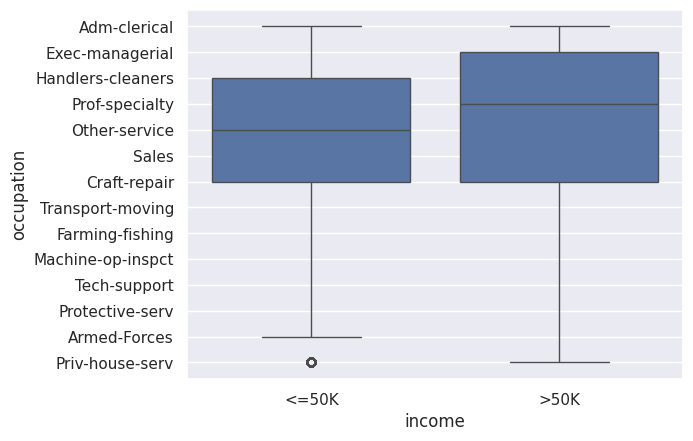

In [66]:
sns.boxplot(data=df,x='income',y='occupation')

plt.show()

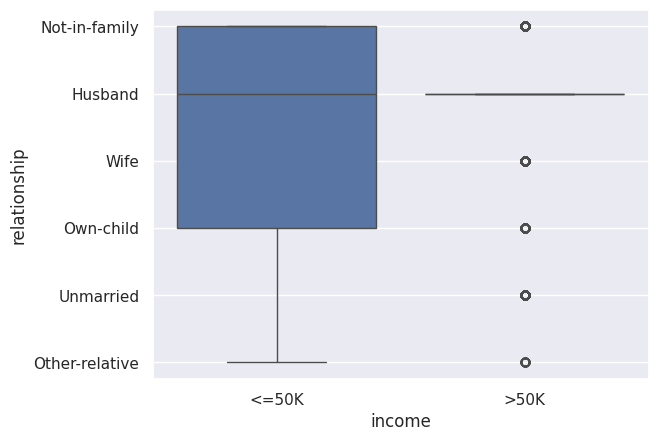

In [67]:
sns.boxplot(data=df,x='income',y='relationship')

plt.show()

In [68]:
cat_df

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'income']

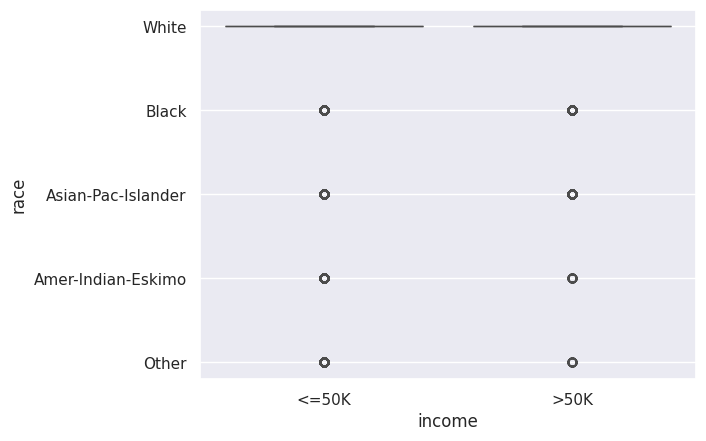

In [69]:
sns.boxplot(data=df,x='income',y='race')

plt.show()

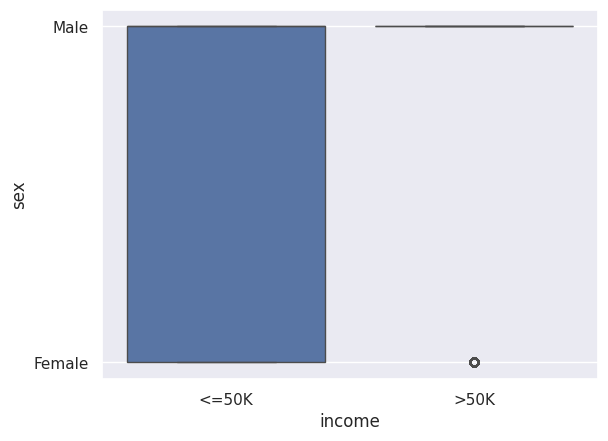

In [70]:
sns.boxplot(data=df,x='income',y='sex')

plt.show()

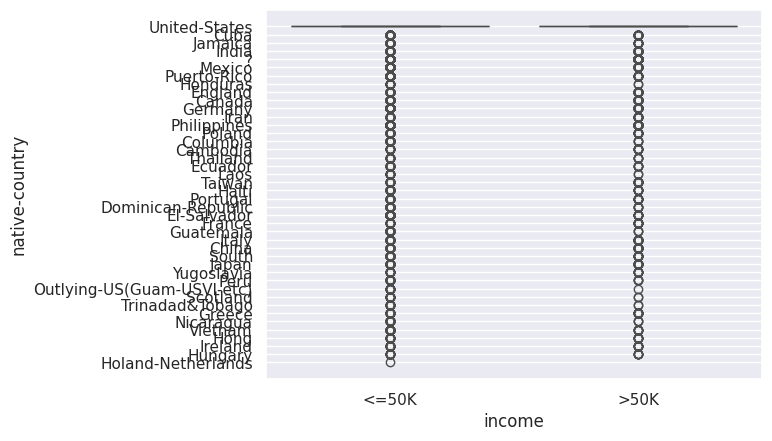

In [71]:
sns.boxplot(data=df,x='income',y='native-country')

plt.show()

all the features contain autliers in relationship to the income variable but it is very much in native country ,

followed by workclass, race and marital statue

In [ ]:
# load the dataframe again

In [72]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [ ]:
# remove the target variable/ dependent variables from the dataframe

In [73]:
X = df.drop('income', axis=1)
y = df['income']



In [74]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States


In [75]:
y

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48836,<=50K
48837,<=50K
48839,<=50K
48840,<=50K


In [76]:
num_df

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

ten insight prepare me for my feature engineering and preprocessing

to determine the skewness of the numerical feature , number of outliers and preprocessing to be done on the feature

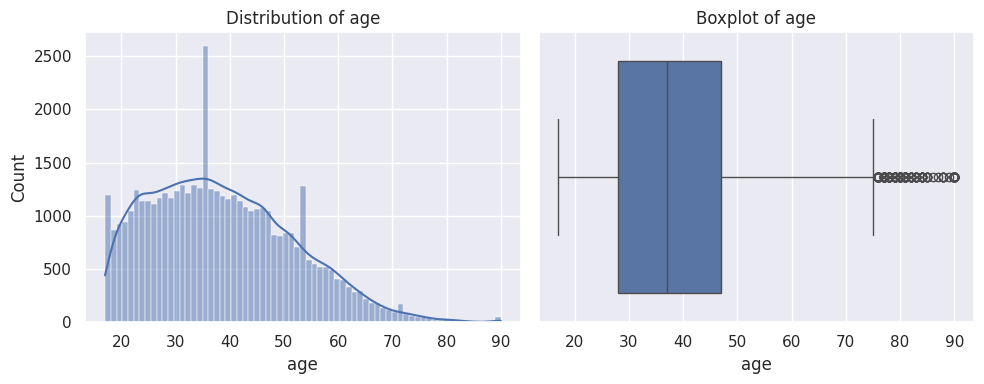

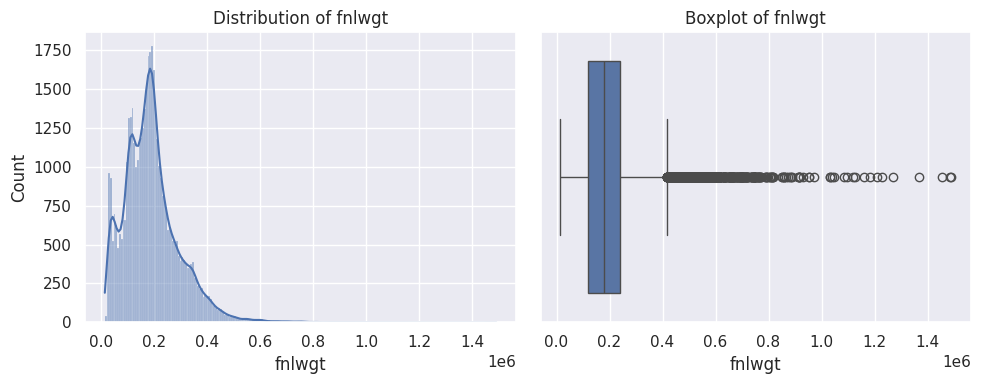

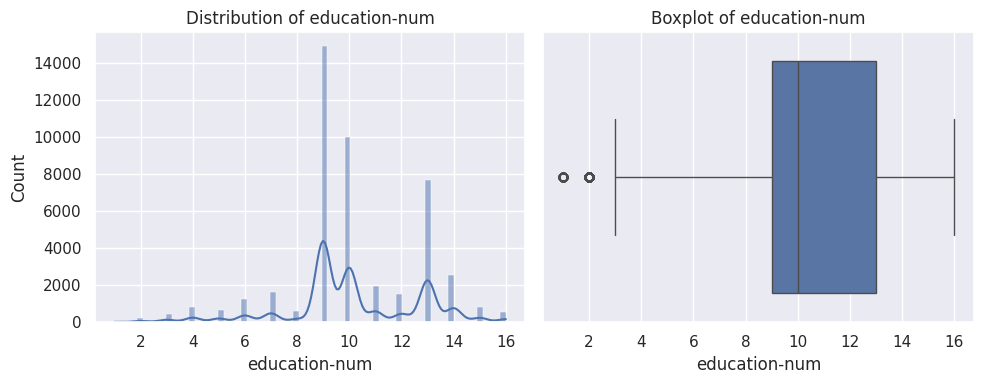

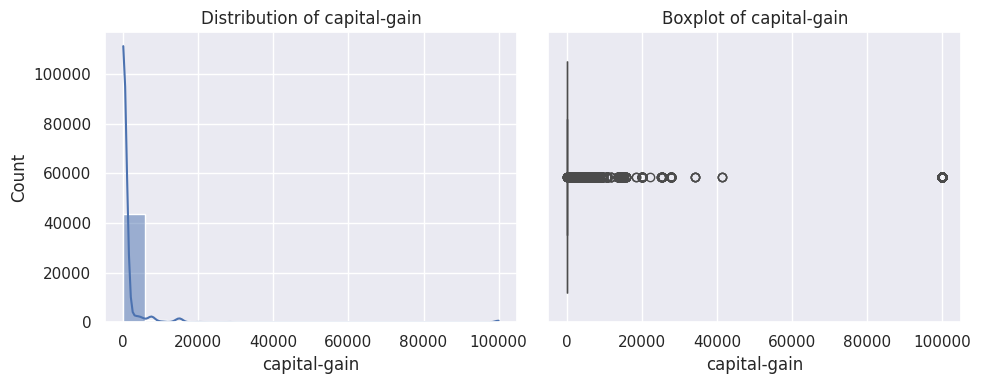

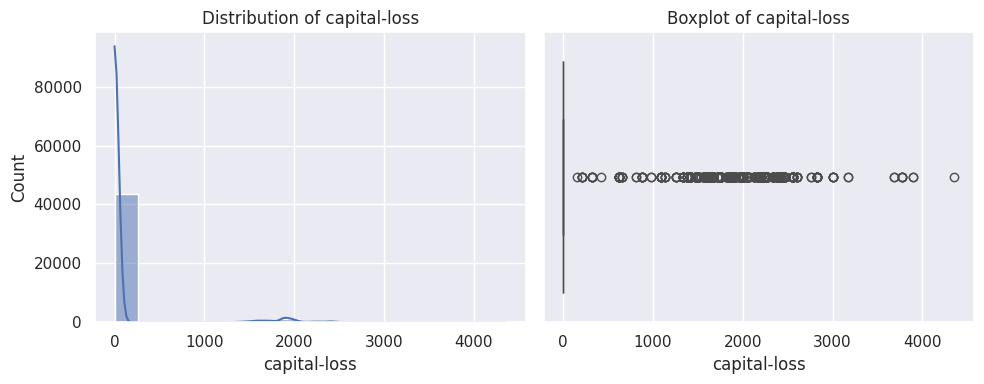

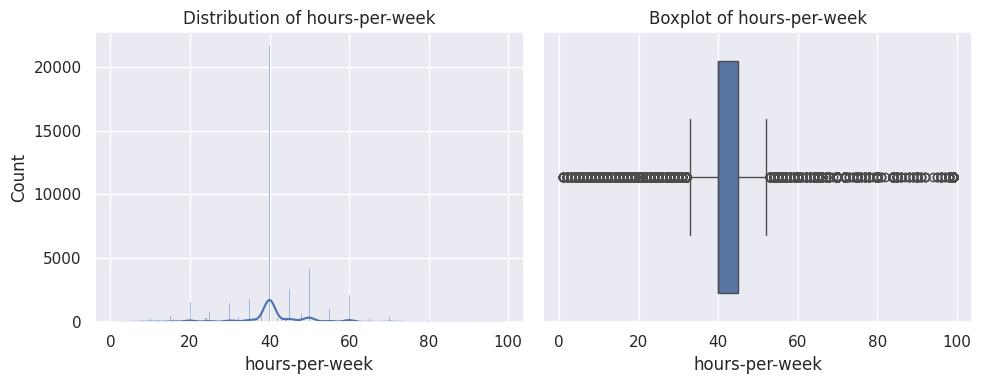

In [77]:
num_df = df.select_dtypes(include='number').columns

for col in num_df:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


In [78]:
skew_values = df[num_df].skew().sort_values(ascending=False)
print(skew_values)


capital-gain      11.707331
capital-loss       4.505678
fnlwgt             1.447012
age                0.532763
hours-per-week     0.342230
education-num     -0.311321
dtype: float64


In [79]:
for col in num_df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    outlier_count = outliers.shape[0]
    print(f"{col}: {outlier_count} outliers")


age: 271 outliers
fnlwgt: 1356 outliers
education-num: 296 outliers
capital-gain: 3841 outliers
capital-loss: 2174 outliers
hours-per-week: 12038 outliers


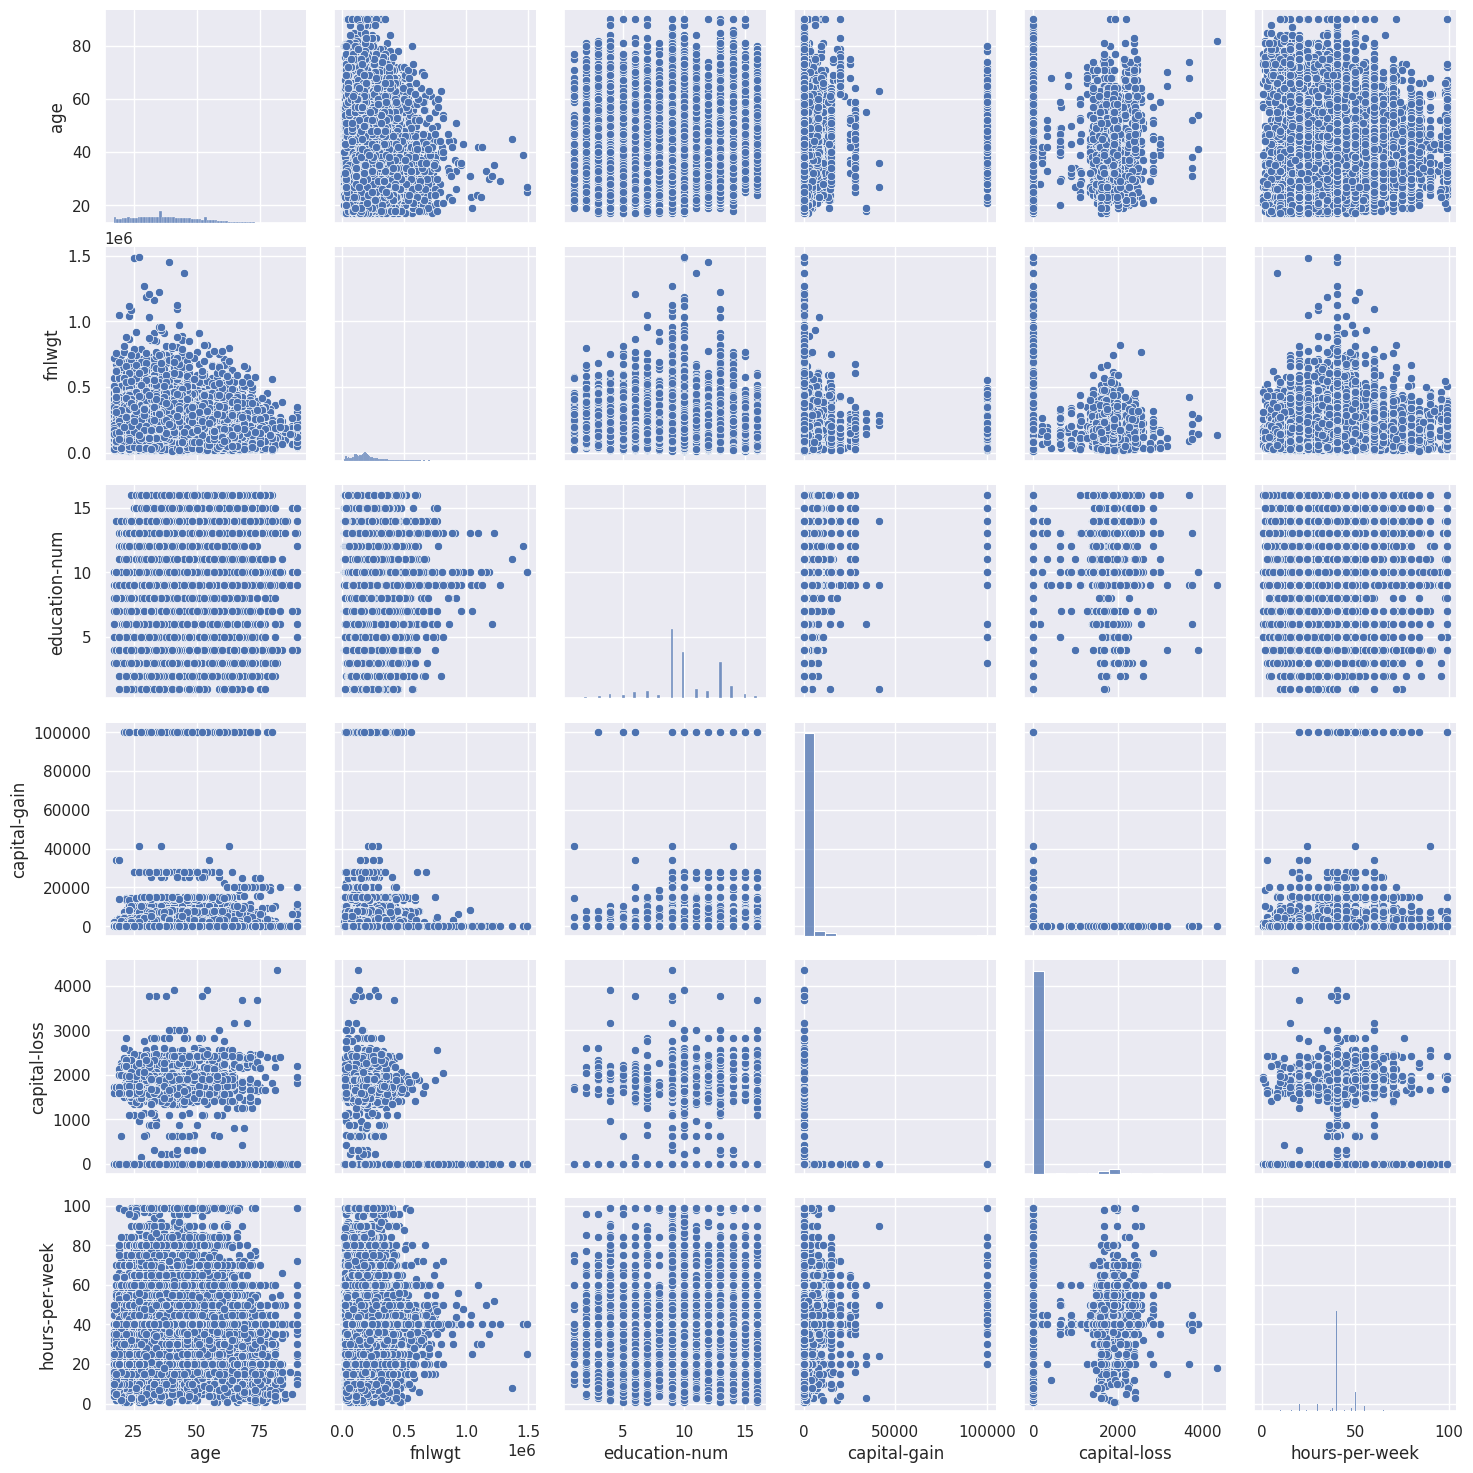

In [80]:
sns.pairplot(df[num_df])

plt.show()

In [81]:
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer, QuantileTransformer

# Step 1: Get numeric features
#num_df = df.select_dtypes(include='number').columns

# Step 2: Prepare summary table
recommendations = []

for col in num_df:
    # Compute skewness
    skew = df[col].skew()

    # Detect outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    outlier_count = outliers.shape[0]

    # Recommendation logic
    if abs(skew) <= 0.5 and outlier_count == 0:
        transformer = "StandardScaler"
    elif outlier_count > 0 and abs(skew) < 1.0:
        transformer = "RobustScaler"
    elif abs(skew) >= 1.0:
        transformer = "QuantileTransformer"
    else:
        transformer = "PowerTransformer"

    recommendations.append({
        'Feature': col,
        'Skewness': round(skew, 3),
        'Outlier_Count': outlier_count,
        'Recommended_Transformer': transformer
    })

# Convert to DataFrame
recommendation_df = pd.DataFrame(recommendations)
print(recommendation_df)

          Feature  Skewness  Outlier_Count Recommended_Transformer
0             age     0.533            271            RobustScaler
1          fnlwgt     1.447           1356     QuantileTransformer
2   education-num    -0.311            296            RobustScaler
3    capital-gain    11.707           3841     QuantileTransformer
4    capital-loss     4.506           2174     QuantileTransformer
5  hours-per-week     0.342          12038            RobustScaler


In [82]:
y

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48836,<=50K
48837,<=50K
48839,<=50K
48840,<=50K


features engineering and preprocessing using sklearn before the model building

then the 11 model training to determine the best model to be selected

In [83]:
# Ensure 'income' exists
assert 'income' in df.columns

# Example target and features
y = df['income']
X = df.drop(columns='income')

# Map labels to binary (you can choose which is 0 or 1)
y = df['income'].map({'<=50K': 0, '>50K': 1})

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [84]:
# Use your actual column names
robust_cols = ['age', 'education-num', 'hours-per-week']
quantile_cols = ['fnlwgt', 'capital-gain', 'capital-loss']
cat_cols = X.select_dtypes(include='object').columns.tolist()


creating pipelines for numerical scaling which are robust_pipeline for 'age', 'education-num', 'hours-per-week' features

 quantile_pipeline for 'fnlwgt', 'capital-gain', 'capital-loss features

 after then cat_pipeline for simple imputed and onehotcoder for categorical features

 lastly columntransformer pipeline for combining them together

In [85]:
robust_pipeline = Pipeline([
    ('scaler', RobustScaler())
])

quantile_pipeline = Pipeline([
    ('quantile', QuantileTransformer(output_distribution='normal'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('robust', robust_pipeline, robust_cols),
    ('quantile', quantile_pipeline, quantile_cols),
    ('cat', cat_pipeline, cat_cols)
])


In [ ]:
# creating object/instant for all the 11 models used

In [86]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(verbose=0),
    'AdaBoost': AdaBoostClassifier(),
    'LightGBM': LGBMClassifier(),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier()
}


In [ ]:
# trained all the 11 model by looping training them
# looping throught the trained  models and determine accuracy metrics and auc-aoc score

In [ ]:
#code to get the performace/accuracy metrics and AUC score for the 11 models

In [1]:
results = []
positive_class = str(sorted(y.unique())[-1])  # dynamically get the positive label

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision': report.get(positive_class, {}).get('precision', 0.0),
        'Recall': report.get(positive_class, {}).get('recall', 0.0),
        'F1-Score': report.get(positive_class, {}).get('f1-score', 0.0),
        'AUC-ROC': auc
    })

results_df = pd.DataFrame(results).sort_values(by='AUC-ROC', ascending=False)
print(results_df)


NameError: name 'y' is not defined

In [ ]:
# catboost model emerged first , followed by xgbboost and lightgbm from the dataframe

In [ ]:
# Create the ROC curve plot
plt.figure(figsize=(12, 8))

# Loop through all already-fitted model pipelines
for name, pipeline in model_pipelines.items():
    try:
        # Get prediction scores
        if hasattr(pipeline.named_steps['model'], "predict_proba"):
            y_scores = pipeline.predict_proba(X_test)[:, 1]
        elif hasattr(pipeline.named_steps['model'], "decision_function"):
            y_scores = pipeline.decision_function(X_test)
        else:
            print(f"⚠️ {name} does not support probability or decision scores.")
            continue

        # Compute ROC curve and AUC
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        auc_score = roc_auc_score(y_test, y_scores)

        # Plot ROC curve
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    except Exception as e:
        print(f"❌ Error for {name}: {e}")

# Add reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Final plot settings
plt.title("AUC-ROC Curve for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'model_pipelines' is not defined

In [ ]:
# to the metric performace in barchat

In [ ]:
# Set style
sns.set(style="darkgrid")

# Melt the DataFrame to long format
results_melted = results_df.melt(id_vars='Model',
                                 value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
                                 var_name='Metric', value_name='Score')

# Create the barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model')

# Add annotations
for i in range(len(results_melted)):
    row = results_melted.iloc[i]
    plt.text(i % 5 + (i // len(results_df)) * 0.2 - 0.2,
             row['Score'] + 0.005,
             f"{row['Score']:.2f}",
             ha='center', fontsize=9)

# Final plot settings
plt.title('Model Performance Comparison')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend()
plt.show()


In [ ]:
# to show the performace of the model in horizaonal barchart

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# Define the metrics to plot (use exact column names from results_df)
metrics = ['Accuracy', 'Precision', 'Recall', 'AUC-ROC']

# Set up the figure with subplots
fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(10, 10), sharex=True)

# Loop through metrics and create horizontal bar plot per metric
for i, metric in enumerate(metrics):
    sns.barplot(
        data=results_df,
        x=metric,
        y='Model',
        ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_xlim(0, 1.05)
    # Add labels to the bars
    for j, p in enumerate(axes[i].patches):
        width = p.get_width()
        axes[i].text(width + 0.01, p.get_y() + p.get_height() / 2,
                     f'{width:.4f}', va='center')

plt.tight_layout()
plt.show()


In [ ]:
# to show the performace metrics of the model focuse only on AUC-ROC score

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort by AUC-ROC
results_df_sorted = results_df.sort_values(by='AUC-ROC', ascending=True)

# Set plot style
sns.set(style="whitegrid")

# Horizontal barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_sorted,
    x='AUC-ROC',
    y='Model',
    palette='viridis'
)

# Annotate scores
for i, score in enumerate(results_df_sorted['AUC-ROC']):
    plt.text(score + 0.005, i, f"{score:.4f}", va='center')

plt.title("Model Comparison Based on AUC-ROC Score")
plt.xlabel("AUC-ROC Score")
plt.xlim(0, 1.05)
plt.ylabel("Model")
plt.tight_layout()
plt.show()


In [ ]:
# barchart showing performance metrics of all the model focing on f1 score the harmonic between precision and the recall

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['F1-Score'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1-Score')
plt.title('F1-Score Comparison of Models (Matplotlib)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


from modeling of 11 models and the visualization done on thier performace metrics and AUC-ROC cure

In [ ]:
# 1. Create pipeline with preprocessor, PCA and CatBoost
catboost_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('pca', PCA(n_components=13)),
    ('model', CatBoostClassifier(verbose=0))
])

# 2. Fit pipeline
catboost_pipeline.fit(X_train, y_train)

# 3. Predict and evaluate
y_pred = catboost_pipeline.predict(X_test)
y_proba = catboost_pipeline.predict_proba(X_test)[:, 1]

# Classification report & AUC
report = classification_report(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print("Classification Report:\n", report)
print(f"AUC-ROC Score: {auc_score:.4f}")


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# Pipeline: preprocessing → SelectKBest → CatBoost
catboost_pipeline = Pipeline([
    ('preprocessing', preprocessor),  # Your existing ColumnTransformer
    ('selectk', SelectKBest(score_func=f_classif, k=12)),  # Select top 12 features
    ('model', CatBoostClassifier(verbose=0))
])

# Fit the pipeline
catboost_pipeline.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = catboost_pipeline.predict(X_test)
y_proba = catboost_pipeline.predict_proba(X_test)[:, 1]

# Classification Report & AUC
report = classification_report(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print("Classification Report:\n", report)
print(f"AUC-ROC Score: {auc_score:.4f}")


In [ ]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# CatBoost pipeline with full preprocessing
catboost_pipeline = Pipeline([
    ('preprocessing', preprocessor),         # your existing ColumnTransformer
    ('model', CatBoostClassifier(verbose=0)) # suppress CatBoost training logs
])

# Fit the pipeline
catboost_pipeline.fit(X_train, y_train)

# Predict
y_pred = catboost_pipeline.predict(X_test)
y_proba = catboost_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

# Print results
print("📊 Classification Report:\n", report)
print(f"⭐ AUC-ROC Score: {auc:.4f}")


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from scipy.stats import randint, uniform

# Step 1: Define the pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),  # your existing ColumnTransformer
    ('model', CatBoostClassifier(verbose=0, random_state=42))
])

# Step 2: Define hyperparameter space
param_dist = {
    'model__iterations': randint(100, 500),
    'model__depth': randint(4, 10),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__l2_leaf_reg': uniform(1, 9),
    'model__border_count': randint(32, 128)
}

# Step 3: RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,  # You can increase for better results
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Step 4: Fit search
random_search.fit(X_train, y_train)

# Step 5: Best model and evaluation
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("✅ Best Parameters:")
print(random_search.best_params_)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print(f"\n⭐ AUC-ROC Score: {roc_auc_score(y_test, y_proba):.4f}")


In [ ]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# CatBoost pipeline with full preprocessing
catboost_pipeline = Pipeline([
    ('preprocessing', preprocessor),         # your existing ColumnTransformer
    ('model', CatBoostClassifier(verbose=0)) # suppress CatBoost training logs
])

# Fit the pipeline
catboost_pipeline.fit(X_train, y_train)

# Predict
y_pred = catboost_pipeline.predict(X_test)
y_proba = catboost_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

# Print results
print("📊 Classification Report:\n", report)
print(f"⭐ AUC-ROC Score: {auc:.4f}")


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get FPR and TPR
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', label=f'CatBoost (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CatBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Extract the trained CatBoost model from pipeline
cat_model = catboost_pipeline.named_steps['model']

# Get feature names after preprocessing
feature_names = catboost_pipeline.named_steps['preprocessing'].get_feature_names_out()

# Get importances
importances = cat_model.feature_importances_

# Create a DataFrame of top 10
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

print(importance_df)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Horizontal bar plot (hastbar)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Important Features - CatBoost (Horizontal)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Vertical bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Feature', y='Importance', palette='magma')
plt.title('Top 10 Important Features - CatBoost (Vertical)')
plt.xticks(rotation=45)
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


In [ ]:
import joblib

# Save the full pipeline
joblib.dump(catboost_pipeline, 'catboost_pipeline_model.pkl')

print("✅ Model saved as 'catboost_pipeline_model.pkl'")


In [ ]:
# Load the saved pipeline
loaded_pipeline = joblib.load('catboost_pipeline_model.pkl')

# Example prediction
y_pred_loaded = loaded_pipeline.predict(X_test)


In [ ]:
y_pred_loaded

array([1, 0, 0, ..., 1, 0, 0], dtype=int64)